## Pullenti test

Датасет: `ScoutieAutoML/russian-news-telegram-dataset`

In [1]:
!pip -q install --no-cache-dir \
    "pandas==2.2.2" \
    "pyarrow==18.1.0" \
    "pullenti-wrapper>=0.1.0" \
    "razdel>=0.5.0" \
    "datasets>=2.20.0" \
    "huggingface_hub" \
    "tqdm" \
    "matplotlib"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 15.4 MB/s eta 0:00:00


In [2]:
import sys
import itertools
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset

from razdel import tokenize as razdel_tokenize

from pullenti_wrapper.langs import set_langs, RU
from pullenti_wrapper.processor import Processor, ADDRESS, GEO
from pullenti_wrapper.referent import (
    AddressReferent,
    GeoReferent,
    StreetReferent,
)

import inspect
from collections import namedtuple

if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")
    def getargspec(func):
        spec = inspect.getfullargspec(func)
        return ArgSpec(spec.args, spec.varargs, spec.varkw, spec.defaults)
    inspect.getargspec = getargspec

print("Python:", sys.version)
print("pandas:", pd.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas: 2.2.2


In [5]:
DATASET_NAME = "ScoutieAutoML/russian-news-telegram-dataset"

# Сколько строк взять для оценки.
SAMPLE_SIZE = 2000
RANDOM_SEED = 42

ds = load_dataset(
    DATASET_NAME,
    split="train",
    streaming=True,
)

ds_shuffled = ds.shuffle(seed=RANDOM_SEED, buffer_size=10000)

rows = []
for item in tqdm(
    itertools.islice(ds_shuffled, SAMPLE_SIZE),
    total=SAMPLE_SIZE,
    desc="Sampling",
):
    text = item.get("text") or ""
    raw_ners = item.get("ners") or []
    ners = [dict(e) for e in raw_ners if isinstance(e, dict)]
    rows.append({"text": text, "ners": ners})

df = pd.DataFrame(rows)

df = df[df["text"].str.len() > 0].reset_index(drop=True)

print("shape:", df.shape)
print("columns:", df.columns.tolist())

display(df.head())

Sampling:   0%|          | 0/2000 [00:00<?, ?it/s]

shape: (2000, 2)
columns: ['text', 'ners']


,text,ners
0,В Москве 19-летний парень отдал мошенникам зол...,"[{'ner': 'Москве', 'lemma': 'москва', 'label':..."
1,МЧС России показало кадры тушения пожара в Чеч...,"[{'ner': 'МЧС', 'lemma': 'мчс', 'label': 'ORG'..."
2,"😂\nДва друга повесили свое фото в Маке, и этог...","[{'ner': 'Маке', 'lemma': 'маке', 'label': 'LO..."
3,Очень странное поведение учителя истории из Ст...,"[{'ner': 'Ставрополья', 'lemma': 'ставрополье'..."
4,"Курьер, которой Лариса Долина отдавала деньги,...","[{'ner': 'Лариса Долина', 'lemma': 'лариса дол..."


In [6]:
gold_label_counter = Counter()

for ners in df["ners"]:
    for ent in ners:
        if not isinstance(ent, dict):
            continue
        gold_label_counter[ent.get("label", "UNKNOWN")] += 1

label_stats = (
    pd.DataFrame(gold_label_counter.items(), columns=["label", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(label_stats)

,label,count
0,LOC,4184
1,ORG,3648
2,NUM,2782
3,PER,2438
4,DATE,347
5,CARDINAL,26
6,PRODUCT,5
7,NORP,5
8,WORK_OF_ART,3
9,FAC,2


In [7]:
TARGET_GOLD_LABEL = "LOC"  # адреса / гео в gold-разметке

set_langs([RU])

# ADDRESS даёт полноценные адреса (ул. Тверская д. 13), GEO — отдельные
# гео-объекты (Москва, Россия). И то, и другое попадает под LOC в датасете.
processor = Processor([ADDRESS, GEO])

In [9]:
def tokenize_with_razdel(text):
    """
    Токенизирует текст razdel'ом.

    Returns:
        tokens:  list[str]              - тексты токенов
        offsets: list[(start, stop)]    - char-границы токенов в исходном тексте
    """
    tokens = []
    offsets = []

    for tok in razdel_tokenize(text):
        tokens.append(tok.text)
        offsets.append((tok.start, tok.stop))

    for tok_text, (start, stop) in zip(tokens, offsets):
        assert text[start:stop] == tok_text, (tok_text, text[start:stop], start, stop)

    return tokens, offsets


def char_spans_to_token_bio(offsets, spans, label):
    """
    Преобразует char-спаны в BIO-теги по токенам.

    offsets: list[(start, stop)] - char-границы каждого токена
    spans:   list[(start, stop)] - char-границы сущностей
    label:   тип сущности для BIO (например, "LOC")
    """
    bio_tags = ["O"] * len(offsets)

    spans_sorted = sorted(spans, key=lambda s: (s[0], -s[1]))

    for span_start, span_stop in spans_sorted:
        if span_start >= span_stop:
            continue

        touched = []

        for token_id, (tok_start, tok_stop) in enumerate(offsets):
            intersects = max(tok_start, span_start) < min(tok_stop, span_stop)

            if intersects:
                touched.append(token_id)

        if not touched:
            continue

        first_token_id = touched[0]

        if bio_tags[first_token_id] == "O":
            bio_tags[first_token_id] = "B-" + label

        for token_id in touched[1:]:
            if bio_tags[token_id] == "O":
                bio_tags[token_id] = "I-" + label

    return bio_tags


def tag_type(tag):
    """
    'B-LOC' -> 'LOC'
    'I-LOC' -> 'LOC'
    'O'     -> 'O'
    """
    tag = str(tag)

    if tag == "O":
        return "O"

    if "-" in tag:
        return tag.split("-", 1)[1]

    return tag


def is_gold_loc(tag):
    return tag_type(tag) == TARGET_GOLD_LABEL


def is_pred_loc(tag):
    return tag_type(tag) == "LOC"

In [10]:
def gold_loc_spans(ners_list):
    """Достаёт char-спаны gold-разметки только для метки LOC."""
    spans = []

    for ent in ners_list:
        if not isinstance(ent, dict):
            continue
        if ent.get("label") != TARGET_GOLD_LABEL:
            continue

        start = ent.get("start_pos")
        stop = ent.get("end_pos")

        if start is None or stop is None:
            continue

        spans.append((int(start), int(stop)))

    return spans


def _referent_kind(ref):
    """Короткое имя типа найденной Pullenti-сущности (для диагностики)."""
    if isinstance(ref, AddressReferent):
        return "address"
    if isinstance(ref, StreetReferent):
        return "street"
    if isinstance(ref, GeoReferent):
        return "geo"
    return type(ref).__name__


MATCH_INFO_KEYS = ("kind", "text", "start_char", "stop_char", "error")


def _empty_match_info(**overrides):
    info = {key: None for key in MATCH_INFO_KEYS}
    info.update(overrides)
    return info


def predict_pullenti_loc(text):
    """
    На вход: сырой текст.
    На выход:
        tokens:    list[str]
        offsets:   list[(start, stop)]
        pred_bio:  list[str]   - BIO-теги LOC по нашей токенизации
        matches:   list[dict]  - найденные Pullenti-сущности, единая схема
                                 (kind, text, start_char, stop_char, error)
    """
    tokens, offsets = tokenize_with_razdel(text)

    loc_spans = []
    matches_info = []

    try:
        result = processor(text)
    except Exception as e:
        matches_info.append(_empty_match_info(
            kind="exception",
            error=str(e),
        ))
        pred_bio = char_spans_to_token_bio(offsets, loc_spans, "LOC")
        return tokens, offsets, pred_bio, matches_info

    for match in result.matches:
        ref = match.referent

        start = int(match.span.start)
        stop = int(match.span.stop)

        if start >= stop:
            continue

        loc_spans.append((start, stop))

        matches_info.append(_empty_match_info(
            kind=_referent_kind(ref),
            text=text[start:stop],
            start_char=start,
            stop_char=stop,
        ))

    pred_bio = char_spans_to_token_bio(offsets, loc_spans, "LOC")

    assert len(pred_bio) == len(tokens)

    return tokens, offsets, pred_bio, matches_info

In [11]:
example_id = None

for i, ners in enumerate(df["ners"]):
    if any(isinstance(e, dict) and e.get("label") == TARGET_GOLD_LABEL for e in ners):
        example_id = i
        break

print("example_id:", example_id)

row = df.iloc[example_id]
text = row["text"]
ners_list = list(row["ners"])

tokens, offsets, pred_bio, matches_info = predict_pullenti_loc(text)

gold_spans = gold_loc_spans(ners_list)
gold_bio = char_spans_to_token_bio(offsets, gold_spans, "LOC")

print("\nTEXT (первые 500 символов):")
print(text[:500])

print("\nTOKEN | GOLD | PRED (только не-O):")
for i, (tok, g, p) in enumerate(zip(tokens, gold_bio, pred_bio)):
    if g != "O" or p != "O":
        print(i, repr(tok), g, p)

print("\nGold LOC-сущности:")
display(pd.DataFrame(
    [e for e in ners_list if isinstance(e, dict) and e.get("label") == TARGET_GOLD_LABEL]
))

print("\nPullenti matches:")
display(pd.DataFrame(matches_info))

example_id: 0

TEXT (первые 500 символов):
В Москве 19-летний парень отдал мошенникам золотые монеты и перевел им более 11 млн рублей «в целях декларирования имущества». Он думал, что участвует в операции ФСБ.
19 октября Артему позвонили «сотрудники ФСБ», а потом и «Центробанка». Они убедили его поучаствовать в секретной спецоперации по поимке мошенников. По указаниям звонивших, Артем взял из сейфа родителей 66 тысяч долларов, а также ордена, медали и украшения и передал их неизвестным, чтобы положить на «безопасный счет».
Этим дело не о

TOKEN | GOLD | PRED (только не-O):
1 'Москве' B-LOC B-LOC
132 'России' O B-LOC

Gold LOC-сущности:


,ner,lemma,label,start_pos,end_pos
0,Москве,москва,LOC,2,8



Pullenti matches:


,kind,text,start_char,stop_char,error
0,geo,Москве,2,8,None
1,geo,России,746,752,None


In [12]:
all_tokens = []
all_gold_bio = []
all_pred_bio = []
all_matches = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Pullenti ADDRESS+GEO"):
    text = row.text
    ners_list = list(row.ners) if row.ners is not None else []

    tokens, offsets, pred_bio, matches_info = predict_pullenti_loc(text)
    gold_spans = gold_loc_spans(ners_list)
    gold_bio = char_spans_to_token_bio(offsets, gold_spans, "LOC")

    assert len(tokens) == len(gold_bio) == len(pred_bio)

    all_tokens.append(tokens)
    all_gold_bio.append(gold_bio)
    all_pred_bio.append(pred_bio)
    all_matches.append(matches_info)

df["tokens"] = all_tokens
df["gold_bio"] = all_gold_bio
df["pullenti_bio"] = all_pred_bio
df["pullenti_matches"] = all_matches

display(df[["text", "tokens", "gold_bio", "pullenti_bio", "pullenti_matches"]].head())

Pullenti ADDRESS+GEO:   0%|          | 0/2000 [00:00<?, ?it/s]

,text,tokens,gold_bio,pullenti_bio,pullenti_matches
0,В Москве 19-летний парень отдал мошенникам зол...,"[В, Москве, 19-летний, парень, отдал, мошенник...","[O, B-LOC, O, O, O, O, O, O, O, O, O, O, O, O,...","[O, B-LOC, O, O, O, O, O, O, O, O, O, O, O, O,...","[{'kind': 'geo', 'text': 'Москве', 'start_char..."
1,МЧС России показало кадры тушения пожара в Чеч...,"[МЧС, России, показало, кадры, тушения, пожара...","[O, B-LOC, O, O, O, O, O, B-LOC, O, O, O, O, O...","[O, B-LOC, O, O, O, O, O, B-LOC, O, O, O, O, O...","[{'kind': 'geo', 'text': 'России', 'start_char..."
2,"😂\nДва друга повесили свое фото в Маке, и этог...","[😂, Два, друга, повесили, свое, фото, в, Маке,...","[O, O, O, O, O, O, O, B-LOC, O, O, O, O, O, O,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",[]
3,Очень странное поведение учителя истории из Ст...,"[Очень, странное, поведение, учителя, истории,...","[O, O, O, O, O, O, B-LOC, O, O, O, O, O, O, O,...","[O, O, O, O, O, O, B-LOC, O, O, O, O, O, O, O,...","[{'kind': 'geo', 'text': 'Ставрополья', 'start..."
4,"Курьер, которой Лариса Долина отдавала деньги,...","[Курьер, ,, которой, Лариса, Долина, отдавала,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-LOC,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, B-LOC,...","[{'kind': 'geo', 'text': 'Москве', 'start_char..."


In [13]:
def compute_token_metrics(df):
    """
    Бинарные токен-уровневые метрики (LOC vs не-LOC):

        pullenti | gold
    tp: loc      | loc
    fp: loc      | not loc
    fn: not loc  | loc
    tn: not loc  | not loc
    """
    tp = fp = fn = tn = 0

    for gold_tags, pred_tags in zip(df["gold_bio"], df["pullenti_bio"]):
        gold_tags = list(gold_tags)
        pred_tags = list(pred_tags)

        assert len(gold_tags) == len(pred_tags)

        for gold_tag, pred_tag in zip(gold_tags, pred_tags):
            gold_is_loc = is_gold_loc(gold_tag)
            pred_is_loc = is_pred_loc(pred_tag)

            if gold_is_loc and pred_is_loc:
                tp += 1
            elif not gold_is_loc and pred_is_loc:
                fp += 1
            elif gold_is_loc and not pred_is_loc:
                fn += 1
            else:
                tn += 1

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def extract_spans_from_bio(bio_tags):
    """
    Из BIO-последовательности собирает спаны (start_token, end_token, label),
    end - exclusive.
    """
    spans = []
    i = 0
    n = len(bio_tags)

    while i < n:
        tag = bio_tags[i]

        if not tag.startswith("B-"):
            i += 1
            continue

        label = tag[2:]
        start = i
        i += 1

        while i < n and bio_tags[i] == "I-" + label:
            i += 1

        spans.append((start, i, label))

    return spans


def compute_entity_metrics(df, label="LOC"):
    """Span-level (exact match) метрики для одной BIO-метки."""
    tp = fp = fn = 0

    for gold_tags, pred_tags in zip(df["gold_bio"], df["pullenti_bio"]):
        gold_spans = {(s, e) for s, e, l in extract_spans_from_bio(gold_tags) if l == label}
        pred_spans = {(s, e) for s, e, l in extract_spans_from_bio(pred_tags) if l == label}

        tp += len(gold_spans & pred_spans)
        fp += len(pred_spans - gold_spans)
        fn += len(gold_spans - pred_spans)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


token_metrics = compute_token_metrics(df)
entity_metrics = compute_entity_metrics(df, label="LOC")

metrics_df = pd.DataFrame([
    {"level": "token_binary_LOC", **token_metrics},
    {"level": "entity_exact_LOC", **entity_metrics},
])

display(metrics_df)

,level,tp,fp,fn,tn,precision,recall,f1
0,token_binary_LOC,3569,764,1394,148649.0,0.823679,0.719121,0.767857
1,entity_exact_LOC,2672,530,1512,NaN,0.834478,0.638623,0.723531


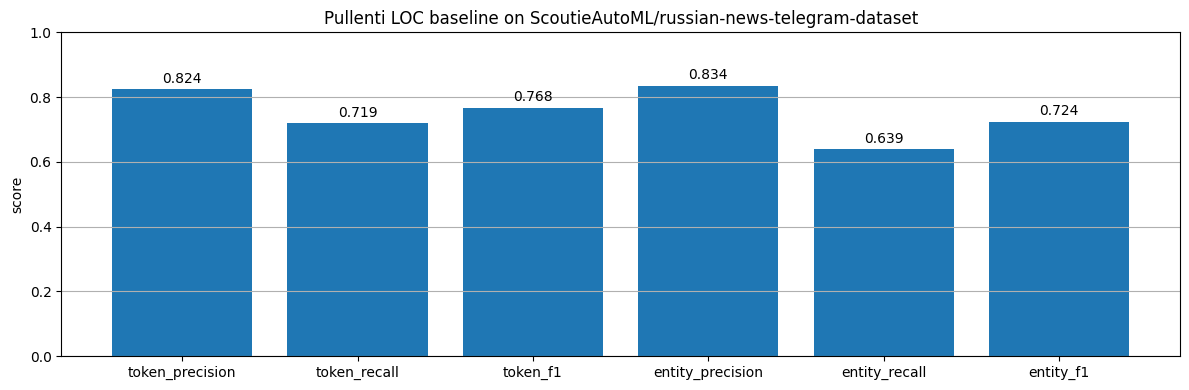

,metric,value
0,token_precision,0.823679
1,token_recall,0.719121
2,token_f1,0.767857
3,entity_precision,0.834478
4,entity_recall,0.638623
5,entity_f1,0.723531


In [14]:
plot_rows = [
    {"metric": "token_precision",  "value": token_metrics["precision"]},
    {"metric": "token_recall",     "value": token_metrics["recall"]},
    {"metric": "token_f1",         "value": token_metrics["f1"]},
    {"metric": "entity_precision", "value": entity_metrics["precision"]},
    {"metric": "entity_recall",    "value": entity_metrics["recall"]},
    {"metric": "entity_f1",        "value": entity_metrics["f1"]},
]

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(12, 4))
plt.bar(plot_df["metric"], plot_df["value"])
plt.ylim(0, 1)
plt.ylabel("score")
plt.title("Pullenti LOC baseline on ScoutieAutoML/russian-news-telegram-dataset")
plt.grid(axis="y")

for i, v in enumerate(plot_df["value"]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

display(plot_df)

In [15]:
error_rows = []

for row_id, row in df.iterrows():
    tokens = list(row["tokens"])
    gold_tags = list(row["gold_bio"])
    pred_tags = list(row["pullenti_bio"])

    for token_id, (token, gold_tag, pred_tag) in enumerate(zip(tokens, gold_tags, pred_tags)):
        gold_is_loc = is_gold_loc(gold_tag)
        pred_is_loc = is_pred_loc(pred_tag)

        if gold_is_loc == pred_is_loc:
            continue

        if gold_is_loc and not pred_is_loc:
            error_type = "FN_missed_by_pullenti"
        else:
            error_type = "FP_extra_by_pullenti"

        error_rows.append({
            "row_id": row_id,
            "token_id": token_id,
            "token": token,
            "gold": gold_tag,
            "pred": pred_tag,
            "error_type": error_type,
            "text": row["text"][:300],
        })

errors_df = pd.DataFrame(error_rows)

print("Errors:", len(errors_df))

if len(errors_df):
    print("\nПо типам ошибок:")
    display(errors_df["error_type"].value_counts())
    display(errors_df.head(200))
else:
    display(errors_df)

Errors: 2158

По типам ошибок:


,count
error_type,
FN_missed_by_pullenti,1394
FP_extra_by_pullenti,764


,row_id,token_id,token,gold,pred,error_type,text
0,0,132,России,O,B-LOC,FP_extra_by_pullenti,В Москве 19-летний парень отдал мошенникам зол...
1,2,7,Маке,B-LOC,O,FN_missed_by_pullenti,"😂\nДва друга повесили свое фото в Маке, и этог..."
2,3,81,Степного,B-LOC,O,FN_missed_by_pullenti,Очень странное поведение учителя истории из Ст...
3,4,24,Кирова,B-LOC,O,FN_missed_by_pullenti,"Курьер, которой Лариса Долина отдавала деньги,..."
4,7,97,ВС,B-LOC,O,FN_missed_by_pullenti,🪖\nПольша не собирается отправлять Украине куп...
...,...,...,...,...,...,...,...
195,176,207,",",O,I-LOC,FP_extra_by_pullenti,#Сводка на утро 30 октября 2024 года\n▪️\nВ\nК...
196,176,208,повреждена,O,I-LOC,FP_extra_by_pullenti,#Сводка на утро 30 октября 2024 года\n▪️\nВ\nК...
197,176,209,линия,O,I-LOC,FP_extra_by_pullenti,#Сводка на утро 30 октября 2024 года\n▪️\nВ\nК...
198,176,216,посёлке,O,B-LOC,FP_extra_by_pullenti,#Сводка на утро 30 октября 2024 года\n▪️\nВ\nК...
